#PRAKTIKUM SISTEM MULTIMEDIA PT(5)

Nama: Catherine V. Pang

NRP/Prodi: 2C22200008 Sains Data VI/A

Tanggal: Selasa, 27 Mei 2025

Materi: Filter Low-High Pass

Rincian Aktivitas Tugas:
1. **Eksperimen dengan filter order**  
   - Gunakan low-pass filter dengan cutoff = 50Hz
   - Bandingkan hasil filtering untuk `order=2`, `order=6`, dan `order=10`
   - Visualisasikan dan jelaskan perbedaannya

2. **Simulasi pada Sinyal Real (opsional)**  
   - Ambil sinyal dari file `.wav` menggunakan `scipy.io.wavfile.read()`
   - Terapkan low-pass dan high-pass filter
   - Simpan hasil filtering ke file baru dan dengarkan perbedaannya


# Desain dan Implementasi Filter Low-Pass dan High-Pass dengan Python

## 1. Pendahuluan

Filter digital digunakan untuk memproses sinyal digital, seperti menghilangkan noise atau mengekstrak komponen sinyal tertentu.

Secara umum, filter terbagi menjadi dua:
- **Low-pass filter**: Melewatkan frekuensi rendah, menahan frekuensi tinggi
- **High-pass filter**: Melewatkan frekuensi tinggi, menahan frekuensi rendah


##Model 0

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter, freqz
import librosa
import soundfile as sf

In [2]:
# Desain filter Butterworth
def butter_lowpass(cutoff, fs, order=5):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return b, a

def butter_highpass(cutoff, fs, order=5):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    return b, a

def apply_filter(data, b, a):
    return lfilter(b, a, data)


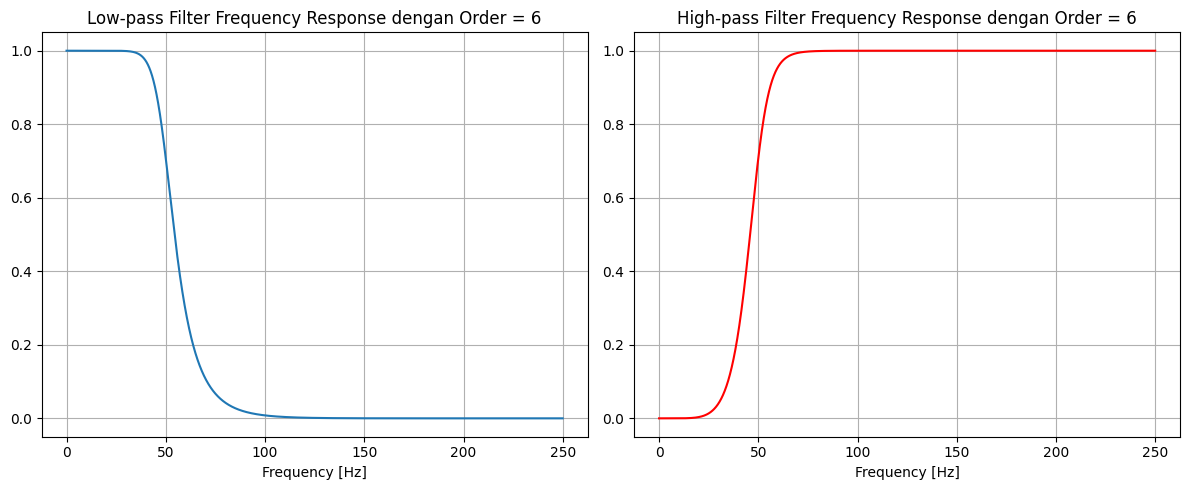

In [29]:
# Parameter
fs = 500       # Sampling frequency
cutoff = 50    # Cut-off frequency
order = 6      # Filter order

# Low-pass filter
b_lp, a_lp = butter_lowpass(cutoff, fs, order)
w_lp, h_lp = freqz(b_lp, a_lp, worN=8000)

# High-pass filter
b_hp, a_hp = butter_highpass(cutoff, fs, order)
w_hp, h_hp = freqz(b_hp, a_hp, worN=8000)

# Plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(0.5*fs*w_lp/np.pi, np.abs(h_lp), label="Low-pass")
plt.title("Low-pass Filter Frequency Response dengan Order = 6")
plt.xlabel("Frequency [Hz]")
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(0.5*fs*w_hp/np.pi, np.abs(h_hp), label="High-pass", color='r')
plt.title("High-pass Filter Frequency Response dengan Order = 6")
plt.xlabel("Frequency [Hz]")
plt.grid()
plt.tight_layout()
plt.show()


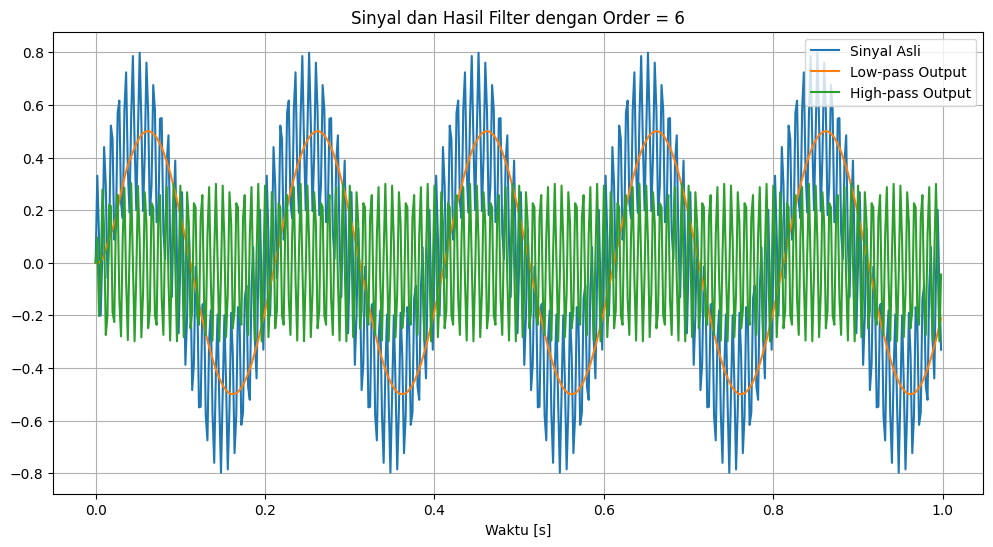

In [30]:
# Buat sinyal: gabungan frekuensi rendah (5Hz) dan tinggi (120Hz)
T = 1.0  # durasi dalam detik
n = int(T * fs)
t = np.linspace(0, T, n, endpoint=False)
x = 0.5*np.sin(2*np.pi*5*t) + 0.3*np.sin(2*np.pi*120*t)

# Aplikasikan filter
y_lp = apply_filter(x, b_lp, a_lp)
y_hp = apply_filter(x, b_hp, a_hp)

# Visualisasi
plt.figure(figsize=(12, 6))
plt.plot(t, x, label='Sinyal Asli')
plt.plot(t, y_lp, label='Low-pass Output')
plt.plot(t, y_hp, label='High-pass Output')
plt.xlabel('Waktu [s]')
plt.legend()
plt.grid()
plt.title('Sinyal dan Hasil Filter dengan Order = 6')
plt.show()


In [6]:
audio_path = librosa.example('trumpet')  # contoh audio trumpet
signal, sr = librosa.load(audio_path, sr=None)  # sr: sampling rate asli

# Parameter filter
cutoff_audio = 1000  # 1kHz
order_audio = 6
b_lp_audio, a_lp_audio = butter_lowpass(cutoff_audio, sr, order_audio)
b_hp_audio, a_hp_audio = butter_highpass(cutoff_audio, sr, order_audio)

# Terapkan filter
filtered_low = apply_filter(signal, b_lp_audio, a_lp_audio)
filtered_high = apply_filter(signal, b_hp_audio, a_hp_audio)

# Simpan hasil ke file
sf.write('output_lowpass0.wav', filtered_low, sr)
sf.write('output_highpass0.wav', filtered_high, sr)
sf.write('original0.wav', signal, sr)

print("File disimpan: original0.wav, output_lowpass0.wav, output_highpass0.wav")

File disimpan: original0.wav, output_lowpass0.wav, output_highpass0.wav


In [13]:
from google.colab import drive
file_path0 = '/content/original0.wav'

# Memuat file audio
import IPython.display as ipd
y, sr = librosa.load(file_path0)
ipd.display(ipd.Audio(data=y,rate=sr))

In [14]:
from google.colab import drive
file_path0 = '/content/output_highpass0.wav'

# Memuat file audio
import IPython.display as ipd
y, sr = librosa.load(file_path0)
ipd.display(ipd.Audio(data=y,rate=sr))

In [15]:
from google.colab import drive
file_path0 = '/content/output_lowpass0.wav'

# Memuat file audio
import IPython.display as ipd
y, sr = librosa.load(file_path0)
ipd.display(ipd.Audio(data=y,rate=sr))

## 6. Kesimpulan

- Filter low-pass menyaring komponen frekuensi tinggi dan mempertahankan sinyal utama.
- Filter high-pass menghilangkan frekuensi rendah, berguna untuk mendeteksi perubahan cepat.
- Python dengan `scipy.signal` sangat powerful untuk desain dan implementasi filter digital.


## 7. Latihan


1. **Eksperimen dengan filter order**  
   - Gunakan low-pass filter dengan cutoff = 50Hz
   - Bandingkan hasil filtering untuk `order=2`, `order=6`, dan `order=10`
   - Visualisasikan dan jelaskan perbedaannya

2. **Simulasi pada Sinyal Real (opsional)**  
   - Ambil sinyal dari file `.wav` menggunakan `scipy.io.wavfile.read()`
   - Terapkan low-pass dan high-pass filter
   - Simpan hasil filtering ke file baru dan dengarkan perbedaannya




#Pengerjaan Tugas

##Model 1 - low-pass filter dengan cutoff = 50Hz,  hasil filtering untuk order=2

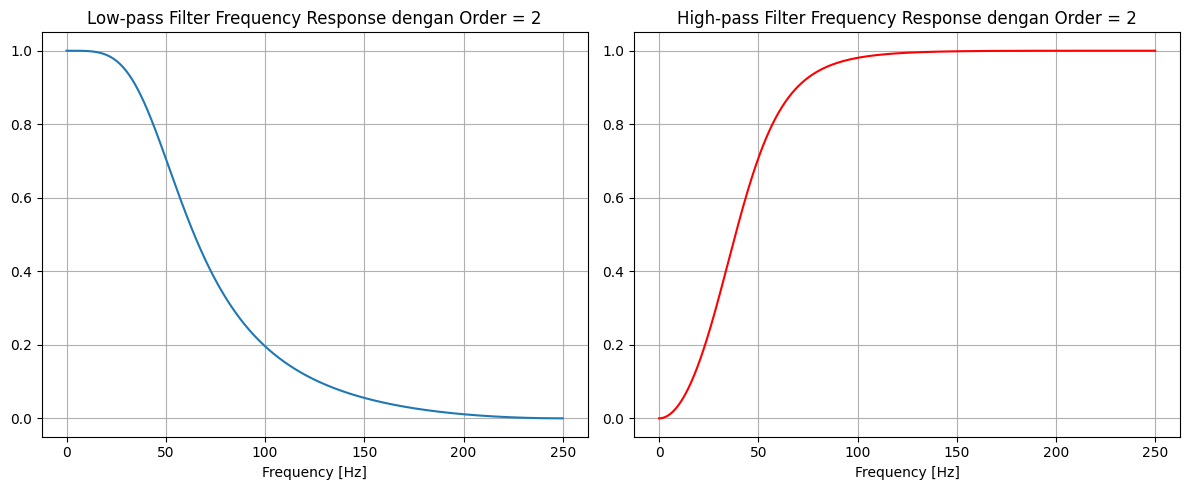

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter, freqz
import librosa
import soundfile as sf

# Desain filter Butterworth
def butter_lowpass(cutoff, fs, order=5):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return b, a

def butter_highpass(cutoff, fs, order=5):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    return b, a

def apply_filter(data, b, a):
    return lfilter(b, a, data)

# Parameter
fs = 500       # Sampling frequency
cutoff = 50    # Cut-off frequency
order = 2      # Filter order

# Low-pass filter
b_lp, a_lp = butter_lowpass(cutoff, fs, order)
w_lp, h_lp = freqz(b_lp, a_lp, worN=8000)

# High-pass filter
b_hp, a_hp = butter_highpass(cutoff, fs, order)
w_hp, h_hp = freqz(b_hp, a_hp, worN=8000)

# Plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(0.5*fs*w_lp/np.pi, np.abs(h_lp), label="Low-pass")
plt.title("Low-pass Filter Frequency Response dengan Order = 2")
plt.xlabel("Frequency [Hz]")
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(0.5*fs*w_hp/np.pi, np.abs(h_hp), label="High-pass", color='r')
plt.title("High-pass Filter Frequency Response dengan Order = 2")
plt.xlabel("Frequency [Hz]")
plt.grid()
plt.tight_layout()
plt.show()

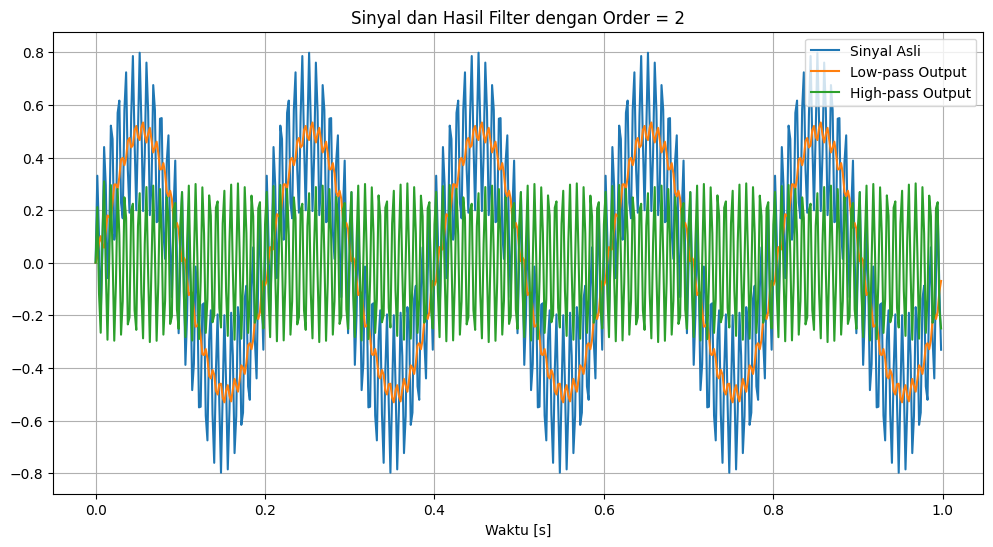

In [32]:
# Buat sinyal: gabungan frekuensi rendah (5Hz) dan tinggi (120Hz)
T = 1.0  # durasi dalam detik
n = int(T * fs)
t = np.linspace(0, T, n, endpoint=False)
x = 0.5*np.sin(2*np.pi*5*t) + 0.3*np.sin(2*np.pi*120*t)

# Aplikasikan filter
y_lp = apply_filter(x, b_lp, a_lp)
y_hp = apply_filter(x, b_hp, a_hp)

# Visualisasi
plt.figure(figsize=(12, 6))
plt.plot(t, x, label='Sinyal Asli')
plt.plot(t, y_lp, label='Low-pass Output')
plt.plot(t, y_hp, label='High-pass Output')
plt.xlabel('Waktu [s]')
plt.legend()
plt.grid()
plt.title('Sinyal dan Hasil Filter dengan Order = 2')
plt.show()


In [18]:
audio_path = librosa.example('trumpet')  # contoh audio trumpet
signal, sr = librosa.load(audio_path, sr=None)  # sr: sampling rate asli

# Parameter filter
cutoff_audio = 1000  # 1kHz
order_audio = 2
b_lp_audio, a_lp_audio = butter_lowpass(cutoff_audio, sr, order_audio)
b_hp_audio, a_hp_audio = butter_highpass(cutoff_audio, sr, order_audio)

# Terapkan filter
filtered_low = apply_filter(signal, b_lp_audio, a_lp_audio)
filtered_high = apply_filter(signal, b_hp_audio, a_hp_audio)

# Simpan hasil ke file
sf.write('output_lowpass1.wav', filtered_low, sr)
sf.write('output_highpass1.wav', filtered_high, sr)
sf.write('original1.wav', signal, sr)

print("File disimpan: original1.wav, output_lowpass1.wav, output_highpass1.wav")

File disimpan: original1.wav, output_lowpass1.wav, output_highpass1.wav


In [19]:
from google.colab import drive
file_path0 = '/content/original1.wav'

# Memuat file audio
import IPython.display as ipd
y, sr = librosa.load(file_path0)
ipd.display(ipd.Audio(data=y,rate=sr))

In [21]:
from google.colab import drive
file_path0 = '/content/output_highpass1.wav'

# Memuat file audio
import IPython.display as ipd
y, sr = librosa.load(file_path0)
ipd.display(ipd.Audio(data=y,rate=sr))

In [22]:
from google.colab import drive
file_path0 = '/content/output_lowpass1.wav'

# Memuat file audio
import IPython.display as ipd
y, sr = librosa.load(file_path0)
ipd.display(ipd.Audio(data=y,rate=sr))

##Model 2 - low-pass filter dengan cutoff = 50Hz,  hasil filtering untuk order=10

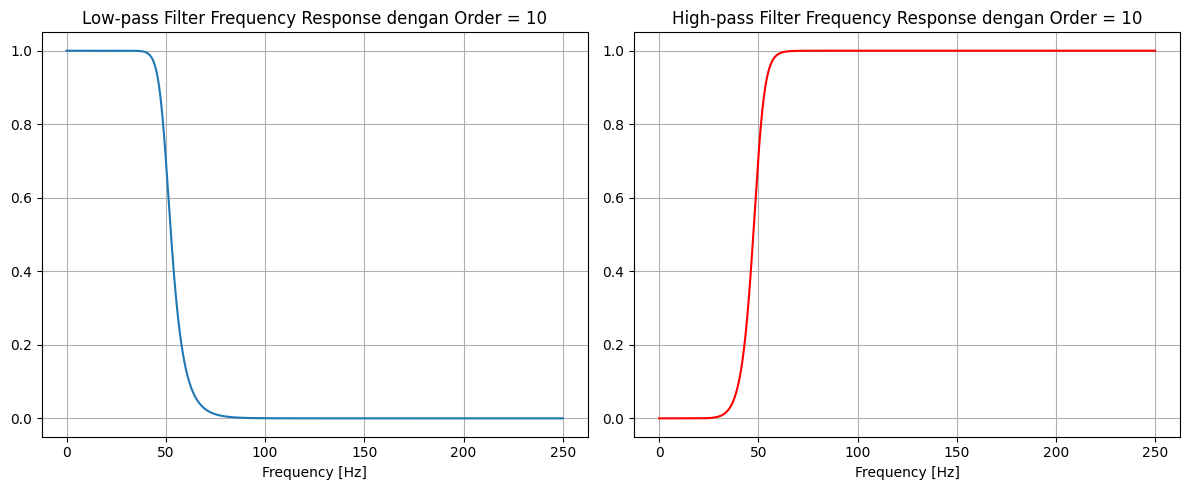

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter, freqz
import librosa
import soundfile as sf

# Desain filter Butterworth
def butter_lowpass(cutoff, fs, order=5):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return b, a

def butter_highpass(cutoff, fs, order=5):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    return b, a

def apply_filter(data, b, a):
    return lfilter(b, a, data)

# Parameter
fs = 500       # Sampling frequency
cutoff = 50    # Cut-off frequency
order = 10      # Filter order

# Low-pass filter
b_lp, a_lp = butter_lowpass(cutoff, fs, order)
w_lp, h_lp = freqz(b_lp, a_lp, worN=8000)

# High-pass filter
b_hp, a_hp = butter_highpass(cutoff, fs, order)
w_hp, h_hp = freqz(b_hp, a_hp, worN=8000)

# Plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(0.5*fs*w_lp/np.pi, np.abs(h_lp), label="Low-pass")
plt.title("Low-pass Filter Frequency Response dengan Order = 10")
plt.xlabel("Frequency [Hz]")
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(0.5*fs*w_hp/np.pi, np.abs(h_hp), label="High-pass", color='r')
plt.title("High-pass Filter Frequency Response dengan Order = 10")
plt.xlabel("Frequency [Hz]")
plt.grid()
plt.tight_layout()
plt.show()

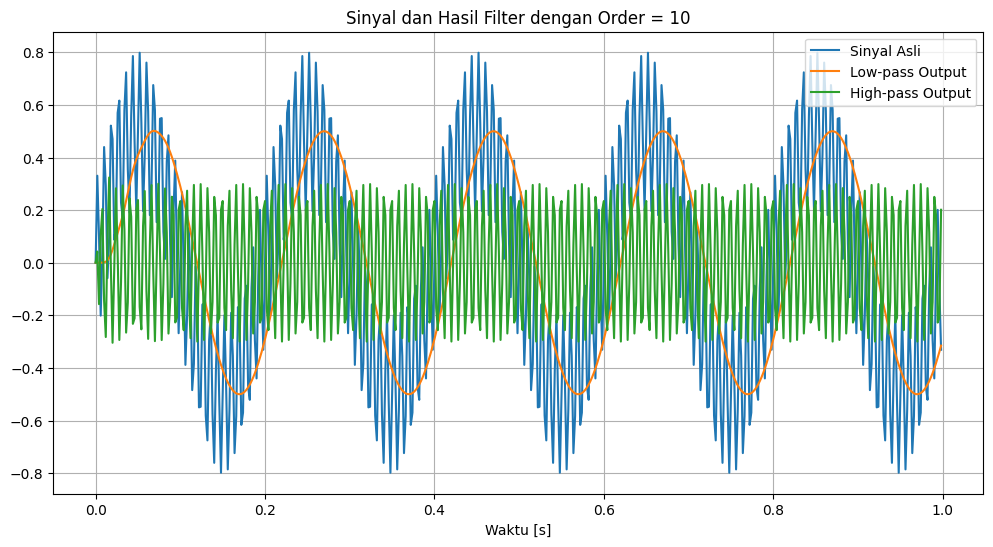

In [34]:
# Buat sinyal: gabungan frekuensi rendah (5Hz) dan tinggi (120Hz)
T = 1.0  # durasi dalam detik
n = int(T * fs)
t = np.linspace(0, T, n, endpoint=False)
x = 0.5*np.sin(2*np.pi*5*t) + 0.3*np.sin(2*np.pi*120*t)

# Aplikasikan filter
y_lp = apply_filter(x, b_lp, a_lp)
y_hp = apply_filter(x, b_hp, a_hp)

# Visualisasi
plt.figure(figsize=(12, 6))
plt.plot(t, x, label='Sinyal Asli')
plt.plot(t, y_lp, label='Low-pass Output')
plt.plot(t, y_hp, label='High-pass Output')
plt.xlabel('Waktu [s]')
plt.legend()
plt.grid()
plt.title('Sinyal dan Hasil Filter dengan Order = 10')
plt.show()

In [25]:
audio_path = librosa.example('trumpet')  # contoh audio trumpet
signal, sr = librosa.load(audio_path, sr=None)  # sr: sampling rate asli

# Parameter filter
cutoff_audio = 1000  # 1kHz
order_audio = 10
b_lp_audio, a_lp_audio = butter_lowpass(cutoff_audio, sr, order_audio)
b_hp_audio, a_hp_audio = butter_highpass(cutoff_audio, sr, order_audio)

# Terapkan filter
filtered_low = apply_filter(signal, b_lp_audio, a_lp_audio)
filtered_high = apply_filter(signal, b_hp_audio, a_hp_audio)

# Simpan hasil ke file
sf.write('output_lowpass2.wav', filtered_low, sr)
sf.write('output_highpass2.wav', filtered_high, sr)
sf.write('original2.wav', signal, sr)

print("File disimpan: original2.wav, output_lowpass2.wav, output_highpass2.wav")

File disimpan: original2.wav, output_lowpass2.wav, output_highpass2.wav


In [26]:
from google.colab import drive
file_path0 = '/content/original2.wav'

# Memuat file audio
import IPython.display as ipd
y, sr = librosa.load(file_path0)
ipd.display(ipd.Audio(data=y,rate=sr))

In [27]:
from google.colab import drive
file_path0 = '/content/output_highpass2.wav'

# Memuat file audio
import IPython.display as ipd
y, sr = librosa.load(file_path0)
ipd.display(ipd.Audio(data=y,rate=sr))

In [28]:
from google.colab import drive
file_path0 = '/content/output_lowpass2.wav'

# Memuat file audio
import IPython.display as ipd
y, sr = librosa.load(file_path0)
ipd.display(ipd.Audio(data=y,rate=sr))

#Interpretasi Pengerjaan Tugas

Ketika orde pada Butterworth low-pass filter dengan cutoff 50 Hz ditingkatkan, terjadi perubahan signifikan baik dalam domain frekuensi maupun domain waktu. Filter orde rendah (2) memiliki roll-off yang relatif landai sekitar 12 dB per oktaf, dengan group delay kecil yang menyebabkan distorsi fase minimal dan respons transient yang halus tanpa overshoot. Namun, attenuasi frekuensi di atas cutoff masih terbatas, sehingga komponen 120 Hz tetap terlihat pada output.  

Sementara itu, filter orde menengah (6) memiliki roll-off lebih curam sekitar 36 dB per oktaf, sehingga lebih mampu menekan sinyal di atas 50 Hz dan lebih bersih dalam memisahkan komponen frekuensi rendah (5 Hz) dari yang lebih tinggi (120 Hz). Meski demikian, group delay lebih besar menyebabkan sinyal terasa tertunda, dan terdapat sedikit ringing atau overshoot di area perubahan cepat.  

Di sisi lain, filter orde tinggi (10) menunjukkan roll-off sangat tajam sekitar 60 dB per oktaf, yang hampir sepenuhnya memblokir komponen di atas cutoff, menghasilkan output yang sangat mendekati sinyal murni 5 Hz. Namun, peningkatan orde ini juga menyebabkan group delay yang lebih signifikan, mengakibatkan output tertunda beberapa sampel serta ringing atau overshoot yang lebih jelas karena fase semakin nonlinear.  

Dari perspektif domain frekuensi, orde rendah memiliki transisi yang lebar, memungkinkan beberapa frekuensi menengah tetap lolos, sedangkan orde tinggi memiliki transisi yang sangat tajam, sehingga hampir tidak ada energi tersisa di atas cutoff. Dalam domain waktu, filter orde rendah memberikan respons yang cepat dengan sedikit delay dan overshoot, sementara orde yang lebih tinggi memiliki delay yang lebih besar serta ringing yang lebih terlihat.  

Oleh karena itu, dalam pemilihan orde filter, perlu mempertimbangkan trade-off antara kecepatan respons dan presisi pemurnian frekuensi. Jika kebutuhan utama adalah real-time dengan sedikit distorsi waktu, maka filter orde rendah adalah pilihan terbaik. Jika memprioritaskan pemisahan frekuensi tanpa terlalu mengkhawatirkan delay, maka orde menengah menawarkan keseimbangan yang baik. Sedangkan jika tujuan utama adalah attenuasi maksimum terhadap frekuensi di atas cutoff dan komputasi bukan masalah, maka penggunaan filter orde tinggi lebih optimal, meskipun dengan konsekuensi delay dan ringing yang lebih besar.  

Kesimpulannya, semakin tinggi orde filter, semakin tajam transisi dan semakin baik attenuasi frekuensi di atas cutoff, namun diikuti dengan peningkatan group delay serta efek ringing yang lebih menonjol. Pemilihan orde harus disesuaikan dengan kebutuhan antara presisi frekuensi dan kecepatan respons.  


Setiap orde pada Butterworth low-pass filter memiliki karakteristik dan efek yang berbeda dalam domain frekuensi serta domain waktu. Berikut adalah perbedaan utama dari masing-masing orde:

### **Orde 2 (Rendah)**
- **Frekuensi**: Roll-off sekitar **12 dB per oktaf**, yang berarti peredaman terhadap frekuensi di atas 50 Hz masih **relatif lemah**. Komponen frekuensi tinggi (misalnya 120 Hz) masih terlihat cukup jelas dalam output filter.  
- **Waktu**: **Group delay kecil**, sehingga distorsi fase hampir tidak terasa. Output filter **cepat menyesuaikan** perubahan sinyal asli tanpa overshoot atau ringing yang signifikan.  
- **Keunggulan**: Sangat baik untuk aplikasi **real-time** karena hampir tidak ada efek samping dalam bentuk delay atau distorsi sinyal.  
- **Kekurangan**: Attenuasi frekuensi tinggi masih terbatas, sehingga efek low-pass kurang optimal untuk memurnikan sinyal.  

### **Orde 6 (Menengah)**
- **Frekuensi**: Roll-off sekitar **36 dB per oktaf**, sehingga **lebih efektif** dalam meredam komponen frekuensi tinggi dibandingkan orde 2. Frekuensi di atas 80 Hz mulai teredam hampir sepenuhnya.  
- **Waktu**: **Group delay meningkat**, menyebabkan sinyal terasa sedikit tertunda. Ada efek **ringing atau overshoot** kecil pada bagian transisi sinyal.  
- **Keunggulan**: Keseimbangan **baik** antara pemurnian frekuensi dan kecepatan respons, cocok untuk aplikasi yang membutuhkan pemisahan sinyal dengan tetap mempertahankan respons yang cukup cepat.  
- **Kekurangan**: Terdapat sedikit overshoot dan delay yang bisa berpengaruh pada sinyal asli.  

### **Orde 10 (Tinggi)**
- **Frekuensi**: Roll-off sangat curam sekitar **60 dB per oktaf**, sehingga **hampir semua** frekuensi di atas 50 Hz terblokir. Output filter sangat mendekati sinyal murni pada 5 Hz tanpa banyak gangguan dari frekuensi lain.  
- **Waktu**: **Group delay signifikan**, menyebabkan output tertunda beberapa sampel. Overshoot dan ringing **paling jelas**, terutama jika sinyal asli mengalami perubahan mendadak.  
- **Keunggulan**: Pemurnian frekuensi **maksimal**, sangat baik untuk aplikasi yang memerlukan filtrasi ketat tanpa kebocoran sinyal dari frekuensi tinggi.  
- **Kekurangan**: Delay dan overshoot **paling besar**, serta membutuhkan **komputasi lebih tinggi**, sehingga kurang ideal untuk aplikasi real-time.  

### **Kesimpulan**
Semakin tinggi orde filter, semakin tajam transisi antara pass-band dan stop-band, serta semakin kuat peredaman terhadap frekuensi di atas cutoff. Namun, peningkatan orde juga menyebabkan **group delay lebih besar**, serta efek **ringing atau overshoot** yang semakin jelas. Pemilihan orde bergantung pada kebutuhan spesifik:  
- **Orde rendah (2–4)** cocok untuk aplikasi **real-time** yang membutuhkan sedikit distorsi.  
- **Orde menengah (6)** memberikan keseimbangan antara pemurnian frekuensi dan kecepatan respons.  
- **Orde tinggi (≥8)** optimal jika fokus utama adalah **attenuasi maksimum** terhadap frekuensi tinggi, meskipun dengan konsekuensi delay dan overshoot lebih besar.  